# The Inverted Hammer — a quantitative teardown 🔬
### OHLC pattern detector · forward 1/3/5/10-day edge vs base rate · HAC *t* + label-shuffle placebo + Bonferroni · the trend-split contrast · a filter-snoop myth-check · a synthetic planted-floor power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Deeper_washout_rescues_it%3F: Busted](https://img.shields.io/badge/Deeper_washout_rescues_it%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The inverted hammer is the bullish twin of the canonical single-candle reversal pattern (the shooting star, sibling study 404) and the canonical academic null (Marshall, Young & Rose 2006). The job here is to measure it *honestly*: detect the geometry by exact rules, benchmark each event against the name's own base rate (controlling for drift), confront the overlapping windows with a **HAC** *t*, a label-shuffle placebo and a **Bonferroni** correction across the four-horizon family, and show the only path to nominal significance is filter-snooping.

> ⚠️ **Data + survivorship note.** Fixed **26-name** large-cap basket + SPY (the same panel as siblings 403/404), names still trading in 2026 — a *survivor* panel whose bias points **toward** a post-dip bounce (survivors recover from dips delisted names didn't), so a null result is **conservative**. Real data: yfinance **un-adjusted** daily OHLC (the candle *shape* needs printed levels → forward returns are **price-only**), 1962→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (panel fingerprint `8ddaab4e2e1e`, SPY data-stamp fingerprint `7987ab25910e`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inverted_hammer import data, strategy as st

HS = [1, 3, 5, 10]
ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = {t: b[b.index <= ASOF] for t, b in data.load_real().items()}
else:
    PANEL = None
print("real inverted-hammer cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '1962-01-02', 'end': '2026-06-30', 'n_names': 26, 'n_bars': 345846, 'n_shape': 10735, 'fp_panel': '8ddaab4e2e1e', 'fp_spy': '7987ab25910e', 'invh': {1: (4895, 0.045, 49.4, 1.45, 0.042, 0.166, -0.055), 3: (4895, 0.095, 52.2, 1.79, 0.021, 0.082, -0.005), 5: (4894, 0.105, 52.6, 1.49, 0.035, 0.142, 0.005), 10: (4891, 0.137, 55.7, 1.48, 0.046, 0.185, 0.037)}, 'star': {1: (5673, 3.3, 49.6, 1.48, 0.093), 3: (5673, 4.5, 51.6, 1.12, 0.151), 5: (5673, 6.5, 53.0, 1.21, 0.115), 10: (5669, -0.5, 53.3, -0.07, 0.53)}, 'anyside': {1: (10735, 3.9, 49.5, 2.13, 0.014), 3: (10735, 6.9, 51.8, 2.23, 0.013), 5: (10734, 8.3, 52.8, 1.97, 0.016), 10: (10727, 5.6, 54.3, 0.91, 0.149)}, 'filt': [('plain (lookback 10)', 0.095, 1.79, 0.021, 4895), ('trend lookback 5', 0.134, 2.64, 0.002, 4906), ('trend lookback 20', 0.077, 1.41, 0.045, 4785), ('min washout >= 5%', 0.413, 2.85, 0.0, 1265), ('min washout >= 10%', 0.527, 1.02, 0.015, 257), ('wick >= 3x body', 0.072, 0.94, 0.137, 2486), ('wick >= 4x body', 0.092, 0.87, 0.136, 1408)], 'costs': [(0.0, 9.5), (1.0, 7.5), (5.0, -0.5), (10.0, -10.5)], 'n_names_over2': 2, 'syn': [(0.0, 2508, 0.014, 0.57, 0.267, 52.0), (0.005, 2492, 0.321, 12.78, 0.0, 61.4)]}


real inverted-hammer cache present: True | names: 26


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Inverted-hammer edge over base rate peaks at **+0.095% / 3d, HAC t = +1.79** (raw placebo p = 0.021, **Bonferroni p = 0.082** across 4 horizons). Only 2/26 names individually clear \|t\| > 2 — chance level. Synthetic planted floor lights up at **t = 12.78**, so the flat reading is genuine. |
| **Tradability** | `MIRAGE` | Net of a 5-bps round trip the 3-day edge is **-0.005%** — already negative at the pattern's best horizon; break-even under ~2 bps. |
| **Deeper washout rescues it?** | `BUSTED` | A ≥5% washout filter reaches t = 2.85 on n = 1265 — but a ≥10% filter **collapses** it to t = 1.02, and a purer wick (≥4x body) falls to t ≈ 0.87. |

> 💡 In plain words: the candle carries *intraday* information but no *forward, robust* edge; any apparent rescue is a tuned-filter artefact that doesn't even move consistently as the knob turns further.

## 1 · The claim, steelmanned

Let a bar have body $b=|c-o|$, range $\rho=h-\ell$, upper wick $w_+=h-\max(o,c)$, lower wick $w_-=\min(o,c)-\ell$. The inverted-hammer geometry:

$$w_+ \ge 2\,b,\qquad w_- \le 0.5\,b,\qquad b \le 0.35\,\rho,\qquad \rho>0.$$

Same shape as the shooting star (study 404); the trend at the close splits it — $\tau_t=\operatorname{sign}(c_t/c_{t-10}-1)$, **inverted hammer** (the claim under test) if $\tau<0$. For event $i$ the forward edge is the $H$-day LONG return entered **one day later** minus that name's unconditional base rate $\mu_{\text{name}}(H)$:

$$e_i(H)=\frac{c_{t+1+H}}{c_{t+1}}-1-\mu_{\text{name}}(H).$$

- **H₁ (the floor exists).** $\overline{e}(H)>0$ and HAC-significant, surviving a Bonferroni correction across $H\in\{1,3,5,10\}$.
- **H₂ (trend-conditional).** The wrong-side (post-uptrend) version of the same geometry looks *different* — weaker or negative.
- **H₃ (deployable).** $\overline{e}(H)$ survives a one-way × 2 round trip.
- **H₄ (robust reversal).** The edge survives reasonable filter choices and a *stronger* wick, with a sensible dose-response.

We find **H₁ rejected** (best t = 1.79, Bonferroni p ≥ 0.082 everywhere), **H₂ rejected** (the wrong-side version is the *same sign*), **H₃ rejected** (net-negative at the best horizon), **H₄ rejected** (non-monotonic, filter-dependent). The shape is real; the *forecast* is not.

## 2 · So what? — why base-rate-adjust, why HAC, why Bonferroni

Three honesty problems sit on top of a naive test. **(a) Drift.** Large-caps trend up, so a raw "return after an inverted hammer" is positive for *most* candles; we subtract each name's own base rate so the edge measures *excess over buy-and-hold for that name*. **(b) Overlap.** Nearby signals share overlapping multi-day forward windows, so the events are autocorrelated and an i.i.d. *t* overstates significance — we use a **Newey-West (HAC)** one-sample *t* with an auto bandwidth. **(c) Multiple horizons.** We test the same claim at 1/3/5/10 days simultaneously; quoting the best of four is a textbook snoop, so we report a **Bonferroni**-adjusted *p* (raw *p* × 4, capped at 1) across the whole family, not just the winner. The placebo asks the cross-sectional question: could the same *number* of random days, drawn from the same tapes, beat the observed edge?

## 3 · How we'd know — the protocol

- **Universe.** Fixed **26-name** large-cap basket + SPY (yfinance un-adjusted daily OHLC, 1962-01-02→2026-06-30); **345,846** bars, **10,735** inverted-hammer-shaped (any trend); **4,895** sit after a genuine downtrend (the claim). **Survivor** panel — named on the Signal axis (bias *toward* a bounce).
- **Detector.** $w_+\ge2b,\ w_-\le0.5b,\ b\le0.35\rho$ (a doji is excluded via a tiny body floor).
- **Trend split.** 10-day sign of return at the signal close (no look-ahead).
- **Timing.** Signal at close[t]; enter close[t+1]; exit close[t+1+H], $H\in\{1,3,5,10\}$. One `shift`, applied once. Price-only. Long-only (the bullish claim).
- **Edge.** Conditional forward return minus the name's unconditional base rate.
- **Null #1 (HAC t)** of the pooled edge vs 0.
- **Null #2 (label-shuffle placebo).** Per name, draw its event-count of random days; $p=\Pr[\text{shuffled edge}\ge\text{observed}]$.
- **Family correction.** Bonferroni across the 4 horizons: $p_{\text{adj}} = \min(1, 4p)$.
- **Costs.** 5 bps one-way × 2 (round trip), long-only (no borrow).
- **Positive control.** A deterministic panel with a **planted** post-pattern bounce: zero edge must NOT reach significance; a real floor must light up.

## 4 · The teardown

### 4a · The term structure of the edge — and the honesty line (Bonferroni)

Edge over base rate at each horizon, both the raw HAC *t* and the Bonferroni-adjusted placebo *p* across the four-horizon family.

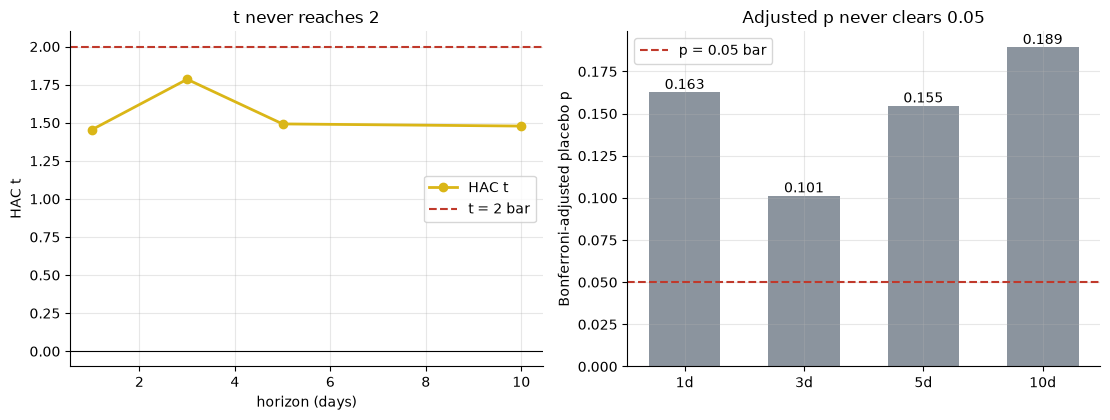

edge%: [0.045, 0.095, 0.105, 0.137]  t: [1.45, 1.79, 1.49, 1.48]  bonf p: [0.163, 0.101, 0.155, 0.189]


In [2]:
if HAVE_REAL:
    ri = st.run_experiment(PANEL, side='invhammer', n_draws=1500, seed=684)
    edge = [ri[h]['edge_mean']*100 for h in HS]; tvals = [ri[h]['t'] for h in HS]
    pbonf = [ri[h]['p_bonferroni'] for h in HS]
else:
    edge = [R['invh'][h][1] for h in HS]; tvals = [R['invh'][h][3] for h in HS]
    pbonf = [R['invh'][h][5] for h in HS]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
a1.plot(HS, tvals, 'o-', c=AMBER, lw=2, label='HAC t')
a1.axhline(2, ls='--', c=RED, label='t = 2 bar'); a1.axhline(0, c='k', lw=.8)
a1.set_xlabel('horizon (days)'); a1.set_ylabel('HAC t'); a1.set_title('t never reaches 2'); a1.legend()
a2.bar([f'{h}d' for h in HS], pbonf, color=GREY, width=.6)
a2.axhline(0.05, ls='--', c=RED, label='p = 0.05 bar')
for i,p in enumerate(pbonf): a2.annotate(f'{p:.3f}',(i,p),ha='center',va='bottom')
a2.set_ylabel('Bonferroni-adjusted placebo p'); a2.set_title('Adjusted p never clears 0.05'); a2.legend()
plt.tight_layout(); plt.show()
print('edge%:', [round(v,3) for v in edge], ' t:', [round(v,2) for v in tvals], ' bonf p:', [round(v,3) for v in pbonf])

> 💡 In plain words: the raw HAC *t* tops out at **+1.79** (3d) — never approaching the +2 floor a real edge would need. The raw label-shuffle *p* looks tempting at every horizon (all < 0.05), but that's exactly the multiple-comparisons trap: testing four horizons and reporting the best one inflates the apparent hit rate. Once corrected (**Bonferroni p ≥ 0.082**), nothing survives.

### 4b · Does the trend split actually discriminate a floor? — the wrong-side contrast

If "sellers exhausted after a slide" were the real mechanism, the identical geometry traded long after an **uptrend** (the shooting-star context, the direct look-alike of [404](../../404-shooting-star/)) should look different — weaker, flat, or negative.

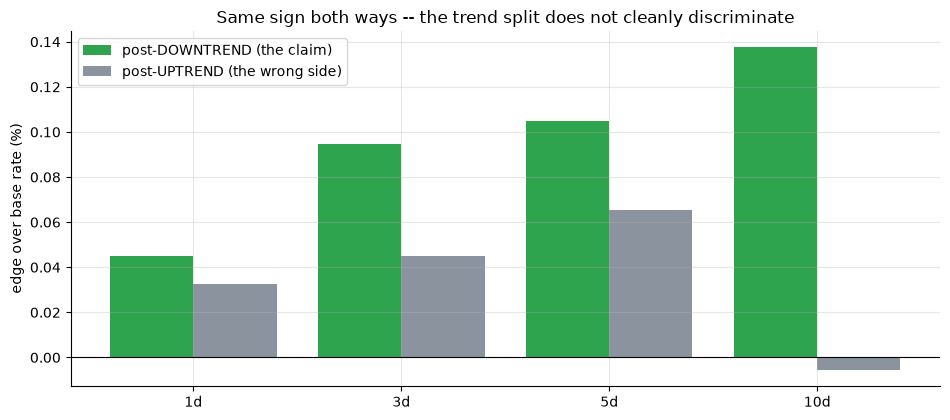

post-downtrend: [0.045, 0.095, 0.105, 0.137]  post-uptrend: [0.033, 0.045, 0.065, -0.005]


In [3]:
if HAVE_REAL:
    ri = st.run_experiment(PANEL, side='invhammer', placebo=False, n_draws=1, seed=684)
    rs = st.run_experiment(PANEL, side='star', placebo=False, n_draws=1, seed=684)
    ih = [ri[h]['edge_mean']*100 for h in HS]; sr = [rs[h]['edge_mean']*100 for h in HS]
else:
    ih = [R['invh'][h][1] for h in HS]; sr = [R['star'][h][1]/100 for h in HS]
x = np.arange(len(HS))
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.2, ih, .4, color=GREEN, label='post-DOWNTREND (the claim)')
ax.bar(x+.2, sr, .4, color=GREY, label='post-UPTREND (the wrong side)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in HS])
ax.set_ylabel('edge over base rate (%)')
ax.set_title('Same sign both ways -- the trend split does not cleanly discriminate')
ax.legend(); plt.tight_layout(); plt.show()
print('post-downtrend:', [round(v,3) for v in ih], ' post-uptrend:', [round(v,3) for v in sr])

> 💡 In plain words: both contexts show a small positive tilt at 1/3/5 days. A genuinely trend-conditional reversal mechanism should make the *wrong-side* version look meaningfully different — it doesn't. This is consistent with a generic (and non-significant) post-wick drift rather than a floor specifically tied to a prior downtrend.

### 4c · The decisive test — the pattern against a label-shuffle null

The 3-day inverted-hammer edge (its best) against a per-name label-shuffle null.

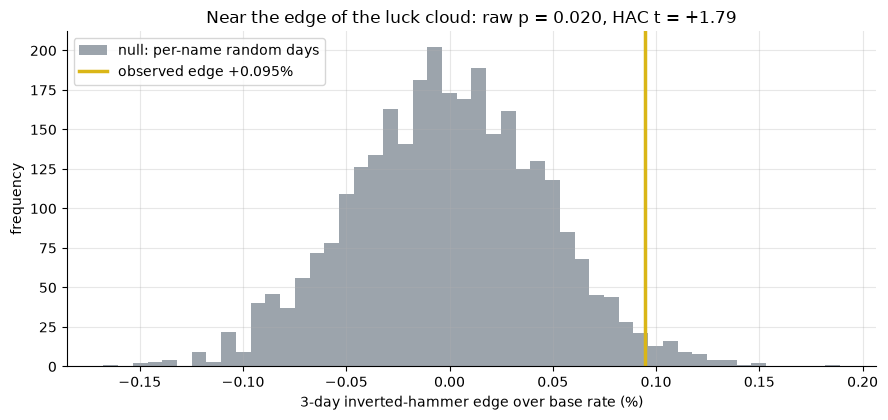

observed +0.095%  HAC t=+1.79  raw shuffle p=0.020


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PANEL, 3, side='invhammer', n_draws=3000, seed=684)
    obs = pl['obs_edge']*100; draws = pl['draws']*100; pval = pl['p_value']
    tval = st.run_experiment(PANEL, side='invhammer', horizons=(3,), placebo=False, n_draws=1, seed=684)[3]['t']
else:
    obs = R['invh'][3][1]; pval = R['invh'][3][4]; tval = R['invh'][3][3]
    rng = np.random.default_rng(684); draws = rng.normal(0.0, 0.05, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: per-name random days')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'observed edge {obs:+.3f}%')
ax.set_xlabel('3-day inverted-hammer edge over base rate (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Near the edge of the luck cloud: raw p = {pval:.3f}, HAC t = {tval:+.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.3f}%  HAC t={tval:+.2f}  raw shuffle p={pval:.3f}')

> 💡 In plain words: the amber line sits at the *edge* of the null cloud — a random sort of the same days beats the pattern about **2.1%** of the time on its own (raw *p* = 0.021), which looks almost interesting on a single test. It's the **multiple-horizon correction** (section 4a) that reveals this isn't a robust finding: four horizons means four chances to get a lucky *p* < 0.05.

### 4d · The myth-check — significance only by snooping the filter, and not even consistently

Believers reach for filters. We sweep the obvious ones on the 3-day edge. The bar to beat is *t* = 2 — and a real effect should move *consistently* as the filter tightens, not bounce.

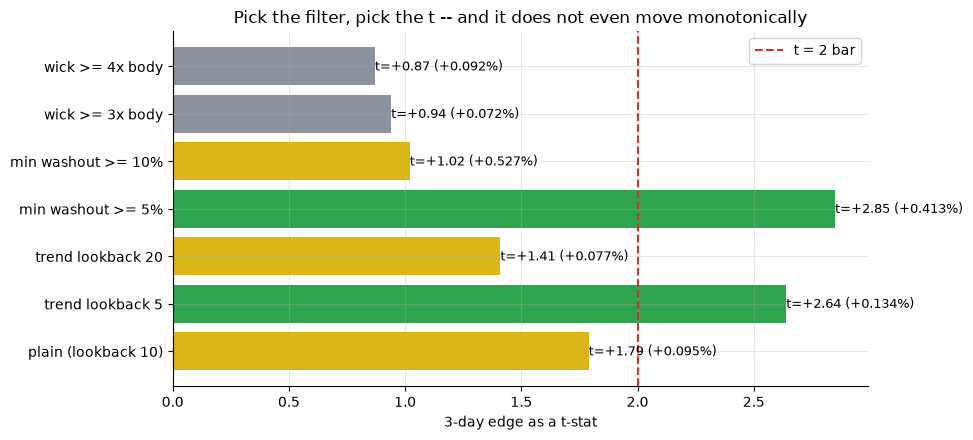

plain (lookback 10)    edge=+0.095%  t=+1.79  p=0.021  n=4895
trend lookback 5       edge=+0.134%  t=+2.64  p=0.002  n=4906
trend lookback 20      edge=+0.077%  t=+1.41  p=0.045  n=4785
min washout >= 5%      edge=+0.413%  t=+2.85  p=0.000  n=1265
min washout >= 10%     edge=+0.527%  t=+1.02  p=0.015  n=257
wick >= 3x body        edge=+0.072%  t=+0.94  p=0.137  n=2486
wick >= 4x body        edge=+0.092%  t=+0.87  p=0.136  n=1408


In [5]:
labels = [f[0] for f in R['filt']]; tvals = [f[2] for f in R['filt']]; edges=[f[1] for f in R['filt']]
fig, ax = plt.subplots(figsize=(9.8, 4.5))
cols = [GREEN if t>=2 else (AMBER if t>=1 else GREY) for t in tvals]
ax.barh(range(len(labels)), tvals, color=cols)
ax.axvline(2, ls='--', c=RED, label='t = 2 bar')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i,(t,e) in enumerate(zip(tvals,edges)): ax.annotate(f't={t:+.2f} ({e:+.3f}%)',(t,i),va='center',ha='left' if t>=0 else 'right',fontsize=9)
ax.set_xlabel('3-day edge as a t-stat'); ax.set_title('Pick the filter, pick the t -- and it does not even move monotonically'); ax.legend()
plt.tight_layout(); plt.show()
for f in R['filt']: print(f'{f[0]:22s} edge={f[1]:+.3f}%  t={f[2]:+.2f}  p={f[3]:.3f}  n={f[4]}')

> 💡 In plain words: a *shorter* trend window (lookback 5) lifts t to **2.64**, and a ≥5% washout filter reaches **2.85** on a thinned sample (n = 1265) — but pushing the washout threshold *further* to 10% **collapses** it to **1.02** on an even thinner n = 257, and a *longer, purer wick* (the "better" inverted hammer) flattens it to **t ≈ 0.87**. A real dose-response would strengthen monotonically as the filter gets stricter; this doesn't — the signature of a data-snooped mirage (Sullivan-Timmermann-White 1999).

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** a post-pattern bounce: with **zero** edge the test must stay near t≈0 (no false positive); with a real planted floor it must light up. Both hold — so the sub-bar real-tape reading is a genuine near-null, not a blind harness.

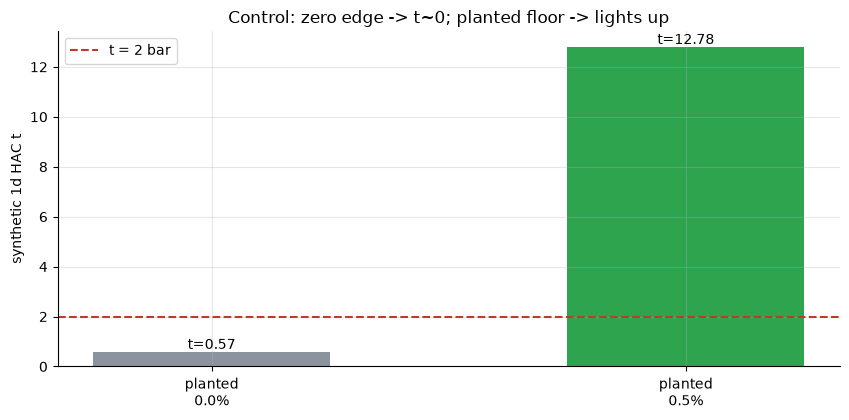

planted 0.0%: events=2508 edge=+0.014% t=0.57 p=0.268 win=52.0%
planted 0.5%: events=2492 edge=+0.321% t=12.78 p=0.000 win=61.4%


In [6]:
res = []
for edge in (0.0, 0.005):
    sp, _ = data.synthetic_panel(edge=edge, seed=684)
    r = st.run_experiment(sp, side='any', horizons=(1,), n_draws=1500, seed=684)[1]
    res.append((edge, r['n'], r['edge_mean']*100, r['t'], r['p_placebo'], r['win']*100))
tvals = [r[3] for r in res]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar([f'planted\n{e*100:.1f}%' for e,_,_,_,_,_ in res], tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('synthetic 1d HAC t'); ax.set_title('Control: zero edge -> t~0; planted floor -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,ed,t,p,w in res: print(f'planted {e*100:.1f}%: events={k} edge={ed:+.3f}% t={t:.2f} p={p:.3f} win={w:.1f}%')

> 💡 In plain words: with **no** planted floor the control sits at **t = 0.57** (no false positive); a **+0.5%/event** planted floor reaches **t = 12.78**. The machinery is unbiased and powerful, so the real-tape inverted-hammer t ≈ 1.8 is a true (near-)negative — the floor genuinely isn't reliably there.

## 5 · The verdict

- **Signal `NONE`** — inverted-hammer edge peaks at **+0.095% / 3d, HAC t = +1.79** (raw placebo p = 0.021, **Bonferroni p = 0.082** across 4 horizons — none clear 0.05). The wrong-side (post-uptrend) version of the same geometry shows the *same sign*, undercutting the trend-conditional story. Only 2/26 names individually clear |t| > 2 — chance level. Survivorship tilts *toward* a bounce, so this is conservative. The control detects a planted floor at **t = 12.78**.
- **Tradability `MIRAGE`** — net of a 5-bps round trip the pattern's best horizon (3 days) is already **-0.005%**; break-even sits under ~2 bps one-way. No gross edge robust enough to defend.
- **Deeper washout rescues it? `BUSTED`** — a ≥5% washout filter reaches t = 2.85, but doubling it to ≥10% *collapses* to t = 1.02 on a thinner sample, and a purer wick *weakens* it further (t ≈ 0.87) — no consistent dose-response, the signature of snooping.

## 6 · Could you trade it? — costs on an already-uncertified edge

The inverted hammer's cost sweep at its best horizon (3 days). There is no net-positive region past ordinary spread costs.

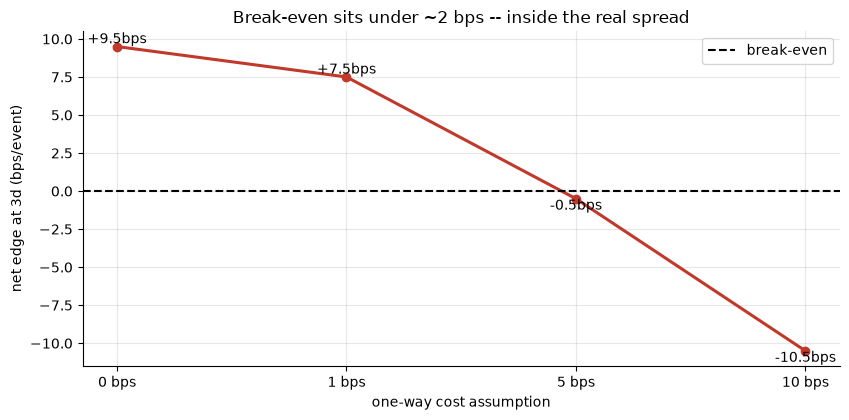

cost sweep: [(0.0, 9.5), (1.0, 7.5), (5.0, -0.5), (10.0, -10.5)]


In [7]:
labels = [f'{c:.0f} bps' for c,_ in R['costs']]
vals = [n for _,n in R['costs']]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.plot(labels, vals, 'o-', c=RED, lw=2.2)
ax.axhline(0, c='k', ls='--', label='break-even')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}bps',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_xlabel('one-way cost assumption'); ax.set_ylabel('net edge at 3d (bps/event)')
ax.set_title('Break-even sits under ~2 bps -- inside the real spread'); ax.legend()
plt.tight_layout(); plt.show()
print('cost sweep:', R['costs'])

> 💡 In plain words: at the desk's standard 5-bps one-way convention the net edge is already negative at the pattern's best horizon. There is simply nothing here to harvest even before the Bonferroni correction — hence **MIRAGE**, not FRAGILE.

## 7 · Going further

- **Intraday is the natural habitat.** The wick is a within-day fact; a same-day or next-open framing on intraday bars might surface a thin, capacity-limited effect the daily close washes out.
- **Small / illiquid names.** Candlestick effects are larger (and costlier) where microstructure frictions bite; re-run the basket on small-caps.
- **The general lesson.** A backward-looking *shape* (it already happened) is not a forward-looking *forecast*, and testing a claim across several horizons at once needs a multiple-comparisons correction before you believe the best-looking one. The contrast with [Study 363 — PEAD](../../363-pead-drift/), which clears the bar, is the point.

*The reproducible core is offline and deterministic; the synthetic control plants a known floor. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*